# Лабораторная работа № 331. Исследование фотоэлементов

**Цель работы.** Изучить вольт-амперные и спектральные характеристики двух
типов фотоэлементов и объяснить качественное различие их свойств:

* **СЦВ-4** — сурьмяно-цезиевый **вакуумный** фотоэлемент;
* **ЦГ-4** — цезиевый **газонаполненный** фотоэлемент.

Работа состоит из двух частей, выполняемых по методике из описания к работе
(файл `data/Квантовая микрофизика.pdf`):

1. **Снятие вольт-амперных характеристик** $J_\phi = f(U)$ — прямой и обратный ход.
2. **Снятие спектральных характеристик** $J_\lambda = J_\phi / \Delta E(\lambda)$ —
   зависимость чувствительности от длины волны при постоянной интенсивности.

Экспериментальные данные взяты из рукописных протоколов измерений
(`data/photos/`, измерения от 06.10).

## 0. Подготовка: импорты и физические константы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# --- единое оформление всех рисунков (тёмно-серая сетка, крупный шрифт) ---
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "figure.dpi": 115,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "legend.framealpha": 0.9,
})
pd.set_option("display.float_format", lambda v: f"{v:.3g}")

# каждый график дополнительно сохраняем в plots/<имя>.png
PLOTS = Path("plots")
PLOTS.mkdir(exist_ok=True)

def save_fig(fig, name):
    """Сохранить рисунок в plots/<name>.png (вызывать до plt.show())."""
    path = PLOTS / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"сохранено: {path}")

C:\Users\Ramil\AppData\Local\Temp\ipykernel_7612\2807836587.py:5: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy import stats


In [2]:
# Физические константы (СИ)
h = 6.626e-34       # постоянная Планка, Дж*с
c = 3.0e8           # скорость света, м/с
k = 1.381e-23       # постоянная Больцмана, Дж/К
eV = 1.602e-19      # электронвольт, Дж

# Параметры установки
T = 2880            # температура нити лампы накаливания, К (из описания)
dx_slit = 0.5       # ширина щели на кожухе фотоэлемента, см

# Обозначения фотоэлементов и единый стиль их отображения
SCV = "СЦВ-4"       # сурьмяно-цезиевый вакуумный
CG  = "ЦГ-4"        # цезиевый газонаполненный

# фирменная палитра работы: бирюзовый (вакуум) и тёплый оранжевый (газ)
PEN = {
    SCV: {"c": "#0E8F86", "fwd": "D", "bwd": "d"},   # teal,  ромбы
    CG:  {"c": "#E06A2C", "fwd": "h", "bwd": "H"},   # amber, шестиугольники
}
# латинские метки для имён файлов в plots/
TAG = {SCV: "SCV-4", CG: "CG-4"}

## Часть 1. Вольт-амперные характеристики

Фотоэлемент включается в цепь по схеме потенциометра; напряжение $U$ подаётся
со стабилизированного источника, ток $J_\phi$ измеряется микроамперметром.
Характеристику снимают дважды — увеличивая $U$ от 0 до 200 В (**прямой ход**)
и уменьшая от 200 В до 0 (**обратный ход**). Характеристики существенно
нелинейны, поэтому для каждой снято 14–15 точек.

Данные ниже перенесены из протокола (фото 1 — ЦГ-4, фото 2 — СЦВ-4).

In [3]:
# --- Вольт-амперные данные (U в вольтах, I в мкА) ---
# СЦВ-4 (вакуумный), фото 2
vac = {
  SCV: {
    "U_fwd": np.array([0, 10.417, 20.885, 30.338, 45.030, 60.06, 75.17, 90.21,
                       105.09, 120.60, 135.33, 150.15, 165.16, 180.28, 200.38]),
    "I_fwd": np.array([0, 1.99, 4.05, 5.49, 7.16, 8.68, 9.91, 10.97,
                       11.87, 13.57, 13.65, 13.71, 13.80, 13.86, 13.90]),
    "U_bwd": np.array([180.05, 165.36, 150.71, 135.49, 120.50, 105.41, 90.64,
                       75.79, 60.60, 45.63, 30.870, 20.970, 10.600, 0]),
    "I_bwd": np.array([13.87, 13.85, 13.83, 13.89, 13.75, 13.34, 11.27,
                       10.30, 9.12, 7.75, 6.08, 4.79, 2.91, 0]),
  },
  # ЦГ-4 (газонаполненный), фото 1
  CG: {
    "U_fwd": np.array([0, 10.047, 20.014, 30.117, 45.297, 60.12, 75.03, 90.26,
                       105.04, 120.75, 135.38, 150.35, 165.23, 180.27, 200.89]),
    "I_fwd": np.array([0, 1.11, 1.26, 1.47, 2.11, 2.60, 3.34, 3.94,
                       4.59, 5.34, 6.16, 7.16, 8.15, 9.02, 10.23]),
    "U_bwd": np.array([180.35, 165.90, 150.67, 135.00, 120.70, 105.33, 90.85,
                       75.56, 60.80, 45.99, 30.950, 20.96, 10.13, 0]),
    "I_bwd": np.array([9.01, 8.20, 7.34, 6.47, 5.70, 4.87, 4.18,
                       3.45, 2.86, 2.26, 1.53, 1.26, 1.04, 0]),
  },
}

# Проверка согласованности длин массивов
for name, d in vac.items():
    assert len(d["U_fwd"]) == len(d["I_fwd"]), name
    assert len(d["U_bwd"]) == len(d["I_bwd"]), name
    print(f"{name}: прямой ход {len(d['U_fwd'])} точек, обратный ход {len(d['U_bwd'])} точек")

СЦВ-4: прямой ход 15 точек, обратный ход 14 точек
ЦГ-4: прямой ход 15 точек, обратный ход 14 точек


### 1.1. Таблицы измерений (прямой ход)

In [4]:
vac_tables = {}
for name, d in vac.items():
    vac_tables[name] = pd.DataFrame({"U, В": d["U_fwd"], "Jφ, мкА": d["I_fwd"]})

print("ВАХ (прямой ход) — две таблицы рядом:")
pd.concat({name: df.reset_index(drop=True) for name, df in vac_tables.items()}, axis=1)

ВАХ (прямой ход) — две таблицы рядом:


СЦВ-4         ЦГ-4        
    U, В Jφ, мкА U, В Jφ, мкА
0      0       0    0       0
1   10.4    1.99   10    1.11
2   20.9    4.05   20    1.26
3   30.3    5.49 30.1    1.47
4     45    7.16 45.3    2.11
5   60.1    8.68 60.1     2.6
6   75.2    9.91   75    3.34
7   90.2      11 90.3    3.94
8    105    11.9  105    4.59
9    121    13.6  121    5.34
10   135    13.7  135    6.16
11   150    13.7  150    7.16
12   165    13.8  165    8.15
13   180    13.9  180    9.02
14   200    13.9  201    10.2

### 1.2. Графики $J_\phi = f(U)$

сохранено: plots\vax_oba_elementa.png


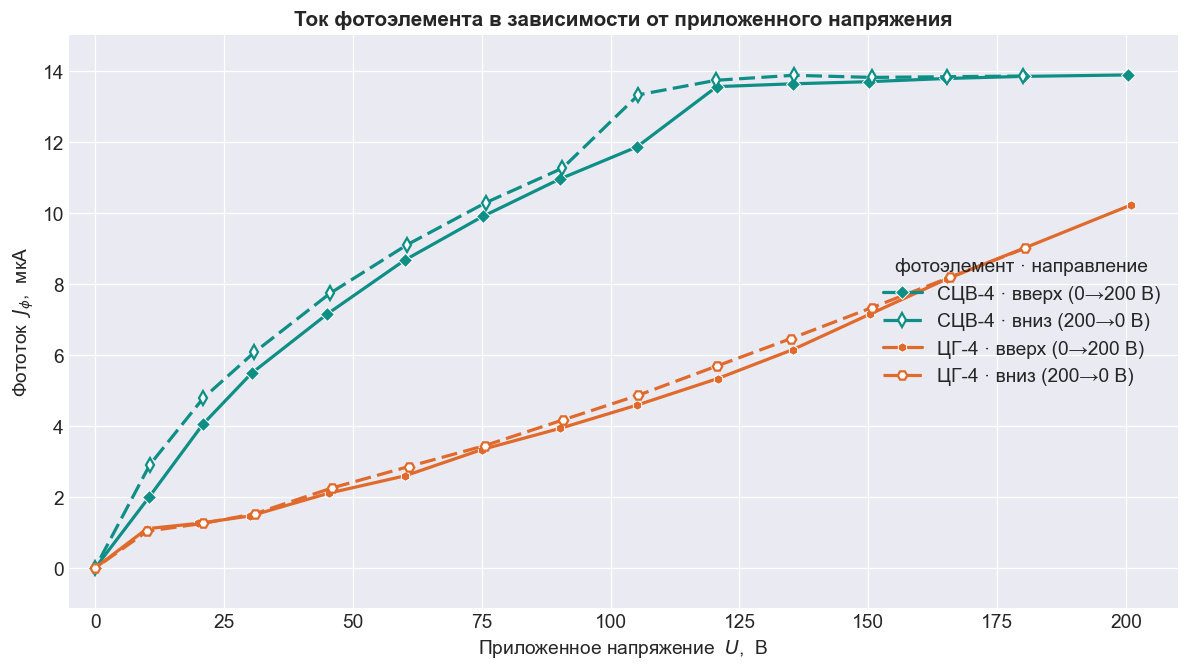

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 6))
ax.set_title("Ток фотоэлемента в зависимости от приложенного напряжения")
ax.set_xlabel("Приложенное напряжение  $U$,  В")
ax.set_ylabel("Фототок  $J_\\phi$,  мкА")

for name, d in vac.items():
    st = PEN[name]
    ax.plot(d["U_fwd"], d["I_fwd"], marker=st["fwd"], color=st["c"],
            ls="-",  mfc=st["c"], mec="white", mew=0.6,
            label=f"{name} · вверх (0→200 В)")
    ax.plot(d["U_bwd"], d["I_bwd"], marker=st["bwd"], color=st["c"],
            ls=(0, (5, 2)), mfc="white", mec=st["c"], mew=1.4,
            label=f"{name} · вниз (200→0 В)")

ax.set_xlim(-5, 210)
ax.margins(y=0.08)
ax.legend(title="фотоэлемент · направление", loc="center right")
plt.tight_layout()
save_fig(fig, "vax_oba_elementa")
plt.show()

Те же данные, но **каждый фотоэлемент на отдельном графике** — так удобнее
разглядеть форму каждой ВАХ по отдельности (насыщение у СЦВ-4 и непрерывный рост
у ЦГ-4).

сохранено: plots\vax_SCV-4.png


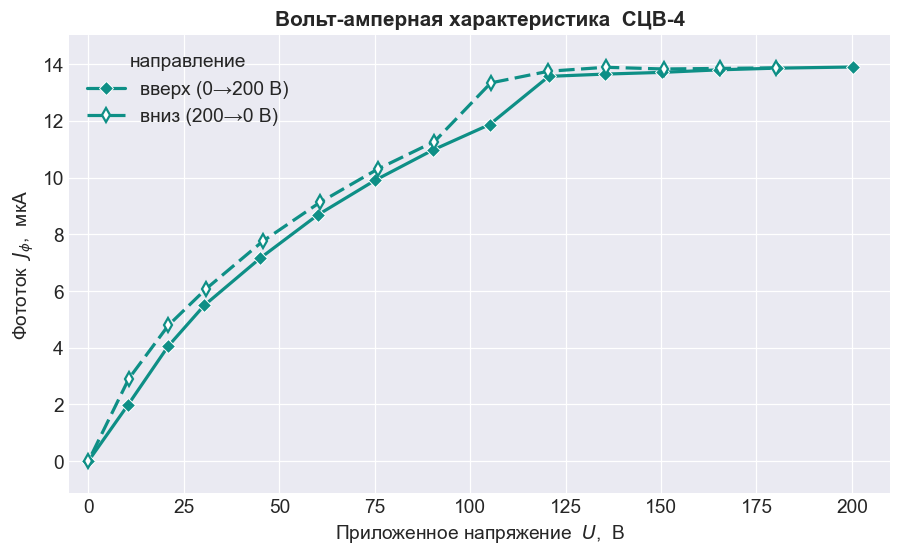

сохранено: plots\vax_CG-4.png


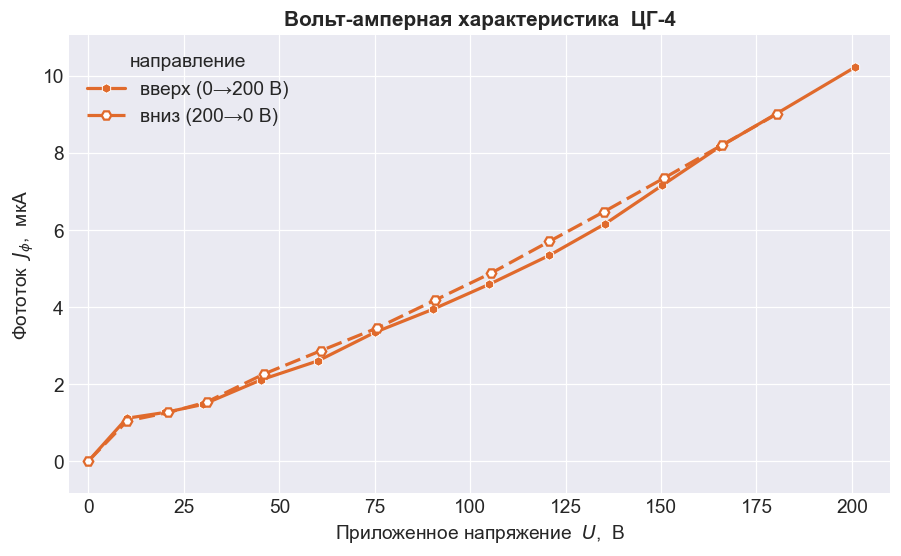

In [6]:
for name, d in vac.items():
    pen = PEN[name]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f"Вольт-амперная характеристика  {name}")
    ax.set_xlabel("Приложенное напряжение  $U$,  В")
    ax.set_ylabel("Фототок  $J_\\phi$,  мкА")

    ax.plot(d["U_fwd"], d["I_fwd"], marker=pen["fwd"], color=pen["c"], ls="-",
            mfc=pen["c"], mec="white", mew=0.6, label="вверх (0→200 В)")
    ax.plot(d["U_bwd"], d["I_bwd"], marker=pen["bwd"], color=pen["c"],
            ls=(0, (5, 2)), mfc="white", mec=pen["c"], mew=1.4,
            label="вниз (200→0 В)")

    ax.set_xlim(-5, 210)
    ax.margins(y=0.08)
    ax.legend(title="направление")
    plt.tight_layout()
    save_fig(fig, f"vax_{TAG[name]}")
    plt.show()

### 1.3. Обсуждение результатов

**Вакуумный элемент СЦВ-4.** Ток быстро растёт с напряжением и выходит на
**насыщение** ($J_\phi \approx 13.9$ мкА при $U \gtrsim 120$ В): при достаточном
поле *все* выбитые фотоэлектроны достигают анода, и ток перестаёт зависеть от
$U$. Прямой и обратный ход практически совпадают — характеристика обратима.

**Газонаполненный элемент ЦГ-4.** Насыщения нет: ток продолжает расти вплоть
до $U \approx 200$ В. Причина — **ударная ионизация** газа: ускоренные полем
электроны ионизуют атомы наполняющего газа, возникает газовое усиление
фототока. Благодаря этому чувствительность выше, но характеристика нелинейна и
зависит от давления газа. Оценка: чтобы электрон набрал на длине свободного
пробега энергию ионизации цезия ($\approx 3.9$ эВ), давление газа внутри
баллона должно быть достаточно низким (порядка единиц–десятков Па), иначе
усиление не наблюдалось бы уже при этих напряжениях.

## Часть 2. Спектральные характеристики

Спектральной характеристикой называют зависимость фототока $J_\phi$ от длины
волны $\lambda$ падающего света при **постоянной интенсивности**. Сплошной
спектр лампы, разложенный призменным монохроматором, проецируется вдоль ящика;
фотоэлемент (с напряжением 200 В) перемещается по шкале $x$ (в см), и в каждой
точке измеряется ток.

Поскольку лампа — не монохроматический источник, измеренный ток нормируют на
энергию, попадающую в фотоэлемент в данном спектральном интервале:

$$ J_\lambda = \frac{J_\phi}{\Delta E(\lambda)} . $$

Эта величина уже не зависит от спектрального состава источника.

### 2.1. Градуировка монохроматора: связь шкалы $x$ и длины волны $\lambda$

Показатель преломления стекла призмы хорошо описывается формулой Коши
$n(\lambda) = a + b/\lambda^2$. Так как координата $x$ на шкале приближённо
пропорциональна углу выхода луча, а тот — показателю преломления, получаем
интерполяционную формулу градуировочного графика $\lambda(x)$ установки:

$$ \ell(\lambda) = A + \frac{B}{\lambda^2}
   \qquad\Longleftrightarrow\qquad
   \lambda(\ell) = \sqrt{\dfrac{B}{\ell - A}} . $$

Коэффициенты $A$ и $B$ берутся из **градуировочного графика конкретной
установки** $\ell(\lambda)$ (фотографии стенда, `photo_1/2_...20-22-11.jpg`).
С графика сняты несколько точек $(\ell,\ \lambda)$ по всему видимому диапазону,
и по ним методом наименьших квадратов (линейная регрессия $\ell$ от $1/\lambda^2$)
найдены $A$ и $B$. Длины волн берём в ангстремах, поэтому $\lambda$ далее
получается в Å.

На градуировочной кривой **$\lambda$ растёт с $\ell$**: красный конец спектра
($\lambda \approx 7000$ Å) соответствует большим $\ell$, фиолетовый
($\approx 4200$ Å) — малым. Поэтому коэффициент $B$ получается **отрицательным**
(а $A > \ell_{\max}$), и подкоренное выражение $B/(\ell-A)$ остаётся
положительным на всей шкале.

In [7]:
# Точки, снятые с градуировочного графика установки (фото ...20-22-11):
# координата шкалы ℓ (см)  ->  длина волны λ (Å). Кривая монотонно возрастает.
ell_cal = np.array([3, 5, 7, 9, 11, 13, 15, 17, 19, 21], float)
lam_cal = np.array([4400, 4560, 4760, 4970, 5200, 5480,
                    5780, 6080, 6350, 6560], float)

# МНК-аппроксимация ℓ = A + B/λ²  (линейна по 1/λ²)
B, A = np.polyfit(1.0 / lam_cal**2, ell_cal, 1)   # slope=B, intercept=A
R2 = 1 - (np.sum((ell_cal - (A + B / lam_cal**2))**2)
          / np.sum((ell_cal - ell_cal.mean())**2))
print(f"A = {A:.3f} см,   B = {B:.4e} см·Å²   (R² = {R2:.4f})")


def l_to_lambda(x):
    """Длина волны (Å) по координате шкалы x (см)."""
    return np.sqrt(B / (x - A))


def dlambda_dx(x):
    """Производная dλ/dx (Å/см): dλ/dx = -(1/2)·λ/(x - A)."""
    return -0.5 * l_to_lambda(x) / (x - A)

A = 33.780 см,   B = -6.0556e+08 см·Å²   (R² = 0.9901)


сохранено: plots\graduirovka_ell_lambda.png


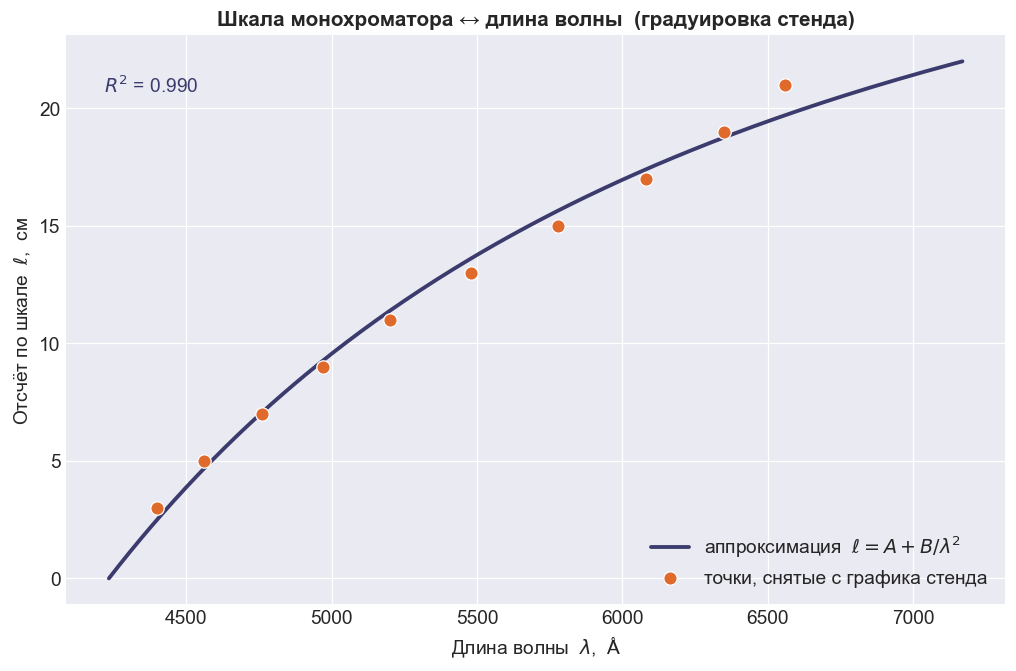

In [8]:
# Градуировочная кривая в тех же осях, что и на стенде: ℓ(λ)
ll = np.linspace(0, 22, 200)
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Шкала монохроматора ↔ длина волны  (градуировка стенда)")
ax.set_xlabel("Длина волны  $\\lambda$,  Å")
ax.set_ylabel("Отсчёт по шкале  $\\ell$,  см")
ax.plot(l_to_lambda(ll), ll, color="#3B3B6D", lw=2.4,
        label=r"аппроксимация  $\ell = A + B/\lambda^2$")
ax.scatter(lam_cal, ell_cal, s=70, color="#E06A2C", edgecolor="white",
           linewidth=0.8, zorder=5, label="точки, снятые с графика стенда")
ax.annotate(f"$R^2$ = {R2:.3f}", xy=(0.04, 0.9), xycoords="axes fraction",
            fontsize=12, color="#3B3B6D")
ax.legend(loc="lower right")
plt.tight_layout()
save_fig(fig, "graduirovka_ell_lambda")
plt.show()

### 2.2. Данные спектральных измерений

Для каждого элемента ток снят вдоль шкалы «туда» (прямой ход) и «обратно»
(фото 3 — прямой ход обоих элементов, фото 4 — обратный ход). Для ЦГ-4 в
области резкого роста тока шаг измельчён до 0.5 см.

In [9]:
# --- Спектральные данные (x в см, I в мкА) ---
spec = {
  # СЦВ-4, фото 3 (прямой) и фото 4 (обратный)
  SCV: {
    "x_fwd": np.arange(0, 23, dtype=float),
    "I_fwd": np.array([0.11, 0.13, 0.14, 0.15, 0.14, 0.16, 0.16, 0.18, 0.18,
                       0.19, 0.20, 0.22, 0.24, 0.24, 0.26, 0.27, 0.23, 0.21,
                       0.18, 0.15, 0.13, 0.12, 0.11]),
    "x_bwd": np.array([21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8,
                       7, 6, 5, 4, 3, 2, 1, 0], dtype=float),
    "I_bwd": np.array([0.12, 0.15, 0.15, 0.17, 0.21, 0.23, 0.26, 0.25, 0.24,
                       0.23, 0.22, 0.20, 0.20, 0.19, 0.18, 0.17, 0.16, 0.17,
                       0.15, 0.14, 0.14, 0.13]),
  },
  # ЦГ-4, фото 3 (прямой) и фото 4 (обратный)
  CG: {
    "x_fwd": np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,
                       17.5,18.0,18.5,19.0,19.5,20.0,20.5,21,21.5,22], dtype=float),
    "I_fwd": np.array([0.11,0.12,0.12,0.13,0.13,0.13,0.13,0.12,0.13,0.14,0.13,
                       0.13,0.13,0.14,0.14,0.14,0.14,0.15,
                       0.15,0.17,0.17,0.18,0.19,0.20,0.21,0.23,0.25,0.28]),
    "x_bwd": np.array([21.5,21.0,20.5,20.0,19.5,19.0,18.5,18.0,17.5,17.0,16.0,
                       15.0,14,13,12,11,10,9,8,7,6,5,4,3,2,1], dtype=float),
    "I_bwd": np.array([0.23,0.23,0.22,0.20,0.18,0.18,0.16,0.15,0.16,0.14,0.14,
                       0.15,0.13,0.13,0.13,0.13,0.13,0.13,0.12,0.12,0.13,0.12,
                       0.13,0.12,0.12,0.12]),
  },
}

for name, d in spec.items():
    assert len(d["x_fwd"]) == len(d["I_fwd"]), name
    assert len(d["x_bwd"]) == len(d["I_bwd"]), name
    print(f"{name}: прямой ход {len(d['x_fwd'])} точек, обратный ход {len(d['x_bwd'])} точек")

СЦВ-4: прямой ход 23 точек, обратный ход 22 точек
ЦГ-4: прямой ход 28 точек, обратный ход 26 точек


### 2.3. Спектральная плотность энергии лампы (формула Планка)

Энергия, попадающая в фотоэлемент в интервале $\Delta\lambda$ около $\lambda$,
пропорциональна спектральной плотности излучения абсолютно чёрного тела при
температуре нити $T$:

$$ \Delta E(\lambda) = E_\lambda\,\Delta\lambda
   = \text{const}\cdot
   \frac{\lambda^{-5}\,\Delta\lambda}{\exp\!\left(\dfrac{hc}{\lambda k T}\right) - 1}. $$

Ширину спектрального интервала, попадающего в щель, находим через производную
градуировочной кривой:

$$ \Delta\lambda = \left|\frac{d\lambda}{dx}\right|\,\Delta x,
   \qquad
   \frac{d\lambda}{dx} = -\frac12\,\frac{\lambda(x)}{x-A}. $$

Постоянный множитель `const` несуществен — спектральные характеристики нужны в
относительных единицах.

In [10]:
def planck_E_lambda(lam_angstrom):
    """Спектральная плотность E_λ (отн. ед.) по формуле Планка.
    lam_angstrom — длина волны в ангстремах."""
    lam_m = lam_angstrom * 1e-10            # Å -> м
    expo = h * c / (lam_m * k * T)
    return lam_m**(-5) / (np.exp(expo) - 1.0)


def spectral_response(x_cm, I):
    """Возвращает (λ[Å], Δλ[Å], ΔE[отн], J_λ[отн]) для набора точек."""
    lam = l_to_lambda(x_cm)
    dlam = np.abs(dlambda_dx(x_cm)) * dx_slit       # Δλ = |dλ/dx|·Δx
    dE = planck_E_lambda(lam) * dlam                 # ΔE(λ)
    J_lam = I / dE                                   # нормированный фототок
    return lam, dlam, dE, J_lam

### 2.4. Расчёт спектральной характеристики $J_\lambda(\lambda)$

Объединяем прямой и обратный ход, переводим координату в длину волны, считаем
$\Delta\lambda$, $\Delta E(\lambda)$ и $J_\lambda = J_\phi/\Delta E$, затем
нормируем $J_\lambda$ на её максимум.

In [11]:
results = {}
for name, d in spec.items():
    x = np.concatenate([d["x_fwd"], d["x_bwd"]])
    I = np.concatenate([d["I_fwd"], d["I_bwd"]])
    lam, dlam, dE, J_lam = spectral_response(x, I)
    order = np.argsort(lam)                    # сортируем по длине волны
    results[name] = {
        "x": x[order], "I": I[order], "lam": lam[order],
        "dlam": dlam[order], "dE": dE[order],
        "J_lam": J_lam[order],
        "J_norm": J_lam[order] / J_lam.max(),
    }
    lam_max = results[name]["lam"][np.argmax(results[name]["J_norm"])]
    print(f"{name}: максимум Jλ при λ ≈ {lam_max/10:.0f} нм "
          f"(у коротковолнового края диапазона)")

СЦВ-4: максимум Jλ при λ ≈ 423 нм (у коротковолнового края диапазона)
ЦГ-4: максимум Jλ при λ ≈ 423 нм (у коротковолнового края диапазона)


### 2.5. Таблица обработки (прямой ход)

Полный расчёт для прямого хода: отсчёт $\ell$ → длина волны $\lambda$ →
интервал $\Delta\lambda$ → энергия лампы $\Delta E$ → нормированный
отклик $J_\lambda$.

In [12]:
def processing_table(name):
    d = spec[name]
    lam, dlam, dE, J_lam = spectral_response(d["x_fwd"], d["I_fwd"])
    J_norm = J_lam / results[name]["J_lam"].max()
    return pd.DataFrame({
        "ℓ, см":      d["x_fwd"],
        "λ, нм":      np.round(lam / 10, 0),
        "Δλ, нм":     np.round(dlam / 10, 1),
        "Jφ, мкА":    d["I_fwd"],
        "ΔE, отн.":   dE,
        "Jλ (норм.)": np.round(J_norm, 3),
    })

print(f"── {SCV} ──")
display(processing_table(SCV))
print(f"── {CG} ──")
processing_table(CG)

── СЦВ-4 ──


,"ℓ, см","λ, нм","Δλ, нм","Jφ, мкА","ΔE, отн.",Jλ (норм.)
0,0,423,3.1,0.11,1.72e+28,0.846
1,1,430,3.3,0.13,1.99e+28,0.864
2,2,437,3.4,0.14,2.31e+28,0.803
3,3,444,3.6,0.15,2.68e+28,0.741
4,4,451,3.8,0.14,3.12e+28,0.594
5,5,459,4,0.16,3.64e+28,0.582
6,6,467,4.2,0.16,4.25e+28,0.498
7,7,476,4.4,0.18,4.98e+28,0.479
8,8,485,4.7,0.18,5.84e+28,0.408
9,9,494,5,0.19,6.87e+28,0.366


── ЦГ-4 ──


,"ℓ, см","λ, нм","Δλ, нм","Jφ, мкА","ΔE, отн.",Jλ (норм.)
0,0,423,3.1,0.11,1.72e+28,1
1,1,430,3.3,0.12,1.99e+28,0.943
2,2,437,3.4,0.12,2.31e+28,0.813
3,3,444,3.6,0.13,2.68e+28,0.759
4,4,451,3.8,0.13,3.12e+28,0.652
5,5,459,4,0.13,3.64e+28,0.559
6,6,467,4.2,0.13,4.25e+28,0.479
7,7,476,4.4,0.12,4.98e+28,0.377
8,8,485,4.7,0.13,5.84e+28,0.348
9,9,494,5,0.14,6.87e+28,0.319


### 2.6. Графики спектральных характеристик

сохранено: plots\spektralnaya_obrabotka.png


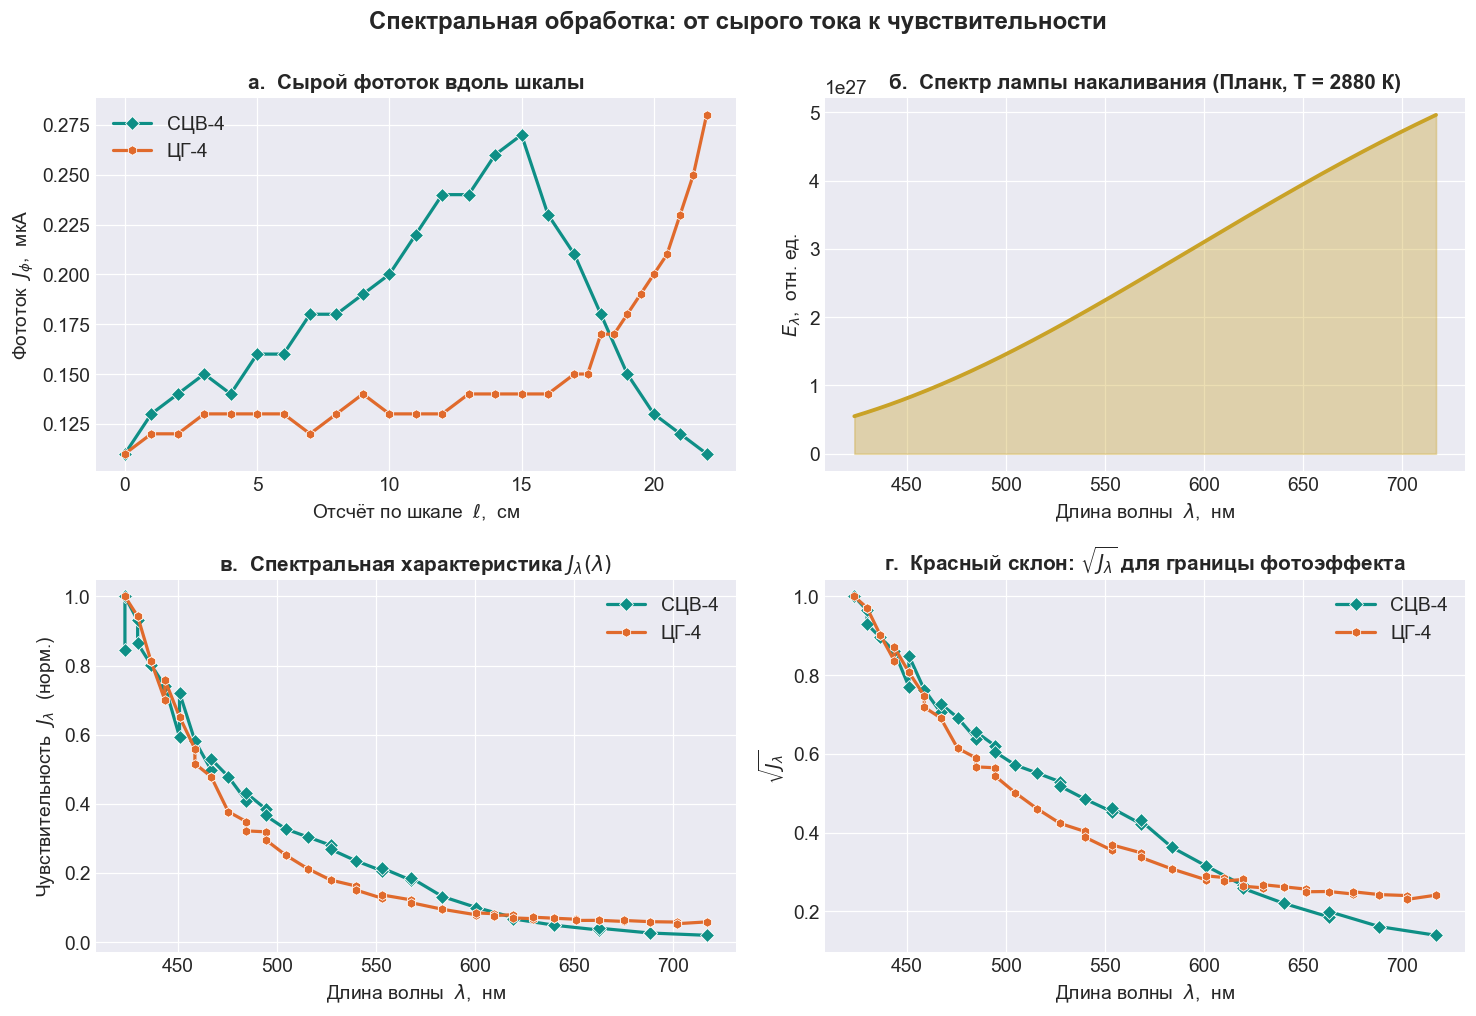

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Спектральная обработка: от сырого тока к чувствительности",
             fontsize=15, fontweight="bold")

def _draw(ax, name, xs, ys, **kw):
    st = PEN[name]
    ax.plot(xs, ys, marker=st["fwd"], color=st["c"], mfc=st["c"],
            mec="white", mew=0.5, label=name, **kw)

# (а) сырой фототок вдоль шкалы
ax = axes[0, 0]
for name in (SCV, CG):
    _draw(ax, name, spec[name]["x_fwd"], spec[name]["I_fwd"])
ax.set_xlabel("Отсчёт по шкале  $\\ell$,  см")
ax.set_ylabel("Фототок  $J_\\phi$,  мкА")
ax.set_title("а.  Сырой фототок вдоль шкалы")
ax.legend()

# (б) спектр лампы по Планку
ax = axes[0, 1]
grid_lam = np.linspace(results[SCV]["lam"].min(), results[SCV]["lam"].max(), 200)
ax.fill_between(grid_lam / 10, planck_E_lambda(grid_lam), color="#C9A227", alpha=0.35)
ax.plot(grid_lam / 10, planck_E_lambda(grid_lam), color="#C9A227", lw=2.4)
ax.set_xlabel("Длина волны  $\\lambda$,  нм")
ax.set_ylabel("$E_\\lambda$,  отн. ед.")
ax.set_title("б.  Спектр лампы накаливания (Планк, T = 2880 К)")

# (в) нормированная спектральная чувствительность
ax = axes[1, 0]
for name in (SCV, CG):
    r = results[name]
    _draw(ax, name, r["lam"] / 10, r["J_norm"])
ax.set_xlabel("Длина волны  $\\lambda$,  нм")
ax.set_ylabel("Чувствительность  $J_\\lambda$  (норм.)")
ax.set_title("в.  Спектральная характеристика $J_\\lambda(\\lambda)$")
ax.legend()

# (г) корень из чувствительности на красном склоне
ax = axes[1, 1]
for name in (SCV, CG):
    r = results[name]
    imax = np.argmax(r["J_norm"])
    _draw(ax, name, r["lam"][imax:] / 10, np.sqrt(r["J_norm"][imax:]))
ax.set_xlabel("Длина волны  $\\lambda$,  нм")
ax.set_ylabel("$\\sqrt{J_\\lambda}$")
ax.set_title("г.  Красный склон: $\\sqrt{J_\\lambda}$ для границы фотоэффекта")
ax.legend()

plt.tight_layout()
save_fig(fig, "spektralnaya_obrabotka")
plt.show()

### 2.7. Анализ спектральных характеристик

**Форма кривых (график в).**

* **СЦВ-4** (сурьмяно-цезиевый): чувствительность максимальна в **сине-фиолетовой**
  области ($\lambda \approx 430$ нм) и монотонно спадает к красному концу почти
  до нуля — типичная характеристика сурьмяно-цезиевого фотокатода.
* **ЦГ-4** (цезиевый): кроме синего максимума у кривой есть **протяжённый
  «хвост» в красной области** ($J_\lambda$ не спадает до нуля, выходит на полку
  $\approx 0.06$) — это начало инфракрасной чувствительности цезия. Полный
  максимум цезия лежит в ИК, за пределами измеренного видимого диапазона.

> Вблизи фиолетового края ($\ell \to 0$) лампа излучает очень мало энергии
> ($\Delta E \to 0$), поэтому деление $J_\phi/\Delta E$ там усиливает
> погрешность — крайние коротковолновые точки наименее надёжны.

**Красная граница и работа выхода.** Вблизи порога фотоэффекта
$\sqrt{J_\lambda}$ линейно зависит от $\lambda$ (приближение закона Фаулера).
Экстраполируя спадающий «красный» склон до $\sqrt{J_\lambda}=0$, оцениваем
красную границу $\lambda_\text{кр}$ и работу выхода $A = hc/\lambda_\text{кр}$.
Оценка корректна только если чувствительность действительно спадает до нуля в
измеренном диапазоне (это выполняется для СЦВ-4).

In [14]:
for name in (SCV, CG):
    r = results[name]
    imax = np.argmax(r["J_norm"])
    # «красный» склон правее максимума
    mask = (np.arange(len(r["lam"])) >= imax) & (r["J_norm"] > 0.03)
    lam_red, sj = r["lam"][mask], np.sqrt(r["J_norm"][mask])
    sl, b, rval, *_ = stats.linregress(lam_red, sj)
    lam_cr = -b / sl                              # где √J_λ = 0, Å
    A_out = h * c / (lam_cr * 1e-10) / eV          # работа выхода, эВ
    tail = r["J_norm"][-1]                         # J_λ на красном краю (≈717 нм)
    if tail < 0.04:        # чувствительность спала практически до нуля
        print(f"[+] {name}:  λ_кр ≈ {lam_cr/10:.0f} нм,  A ≈ {A_out:.2f} эВ  "
              f"(линейность r = {rval:.3f})")
    else:                  # осталась «полка» → истинная граница дальше в ИК
        print(f"[~] {name}:  формально λ_кр ≈ {lam_cr/10:.0f} нм, "
              f"A ≈ {A_out:.2f} эВ, но в красной области остаётся полка "
              f"(Jλ ≈ {tail:.2f}) — это лишь нижняя оценка, истинная граница "
              f"цезия лежит в ИК.")

[+] СЦВ-4:  λ_кр ≈ 699 нм,  A ≈ 1.77 эВ  (линейность r = -0.982)
[~] ЦГ-4:  формально λ_кр ≈ 745 нм, A ≈ 1.67 эВ, но в красной области остаётся полка (Jλ ≈ 0.06) — это лишь нижняя оценка, истинная граница цезия лежит в ИК.


## Выводы

1. Сняты вольт-амперные характеристики вакуумного (СЦВ-4) и газонаполненного
   (ЦГ-4) фотоэлементов. У СЦВ-4 ток выходит на **насыщение**
   ($\approx 13.9$ мкА), у ЦГ-4 насыщения нет из-за **газового усиления**
   (ударной ионизации) — ток растёт вплоть до 200 В.
2. Прямой и обратный ход ВАХ практически совпадают — характеристики обратимы.
3. Шкала монохроматора проградуирована по графику стенда $\ell(\lambda)$:
   аппроксимация $\ell = A + B/\lambda^2$ (МНК, $R^2 \approx 0.99$) даёт
   соответствие $\ell = 0\ldots22$ см $\leftrightarrow \lambda \approx
   420\ldots720$ нм (красный конец — при больших $\ell$).
4. Сняты и обработаны спектральные характеристики: фототок пересчитан в
   $J_\lambda = J_\phi/\Delta E(\lambda)$ с учётом спектра лампы (формула
   Планка) и ширины интервала $\Delta\lambda$.
5. **СЦВ-4** чувствителен в сине-фиолетовой области ($\lambda_\max \approx 430$
   нм), к красному краю чувствительность спадает; по её спаду оценены красная
   граница и работа выхода. **ЦГ-4** кроме синего максимума сохраняет
   чувствительность в красной области (начало ИК-чувствительности цезия),
   поэтому его красная граница лежит за пределами видимого диапазона.

## Контрольные вопросы

### 1) Основные законы фотоэффекта и их классическая необъяснимость
- **Уравнение Эйнштейна:** $E_k = h\nu - A$ — кинетическая энергия
  фотоэлектронов линейно растёт с частотой и не зависит от интенсивности.
- **Красная граница:** существует $\nu_\min = A/h$, ниже которой фотоэффект
  невозможен при любой интенсивности.
- **Число фотоэлектронов** пропорционально интенсивности (числу фотонов).
- **Безынерционность:** эффект возникает практически мгновенно.

Классическая волновая теория не может объяснить ни красную границу, ни
независимость энергии электронов от интенсивности, ни безынерционность —
энергия должна была бы «накапливаться».

### 2) Другие проявления квантовых свойств излучения
Эффект Комптона, тепловое излучение АЧТ (формула Планка), опыт Боте,
коротковолновая граница тормозного рентгеновского спектра, давление света на
уровне отдельных фотонов.

### 3) Закономерности равновесного (теплового) излучения
Закон Кирхгофа, формула Планка
$u(\nu,T)=\dfrac{8\pi h\nu^3}{c^3}\dfrac{1}{e^{h\nu/kT}-1}$, закон смещения
Вина $\lambda_\max=b/T$, закон Стефана–Больцмана $R=\sigma T^4$, предельный
классический закон Рэлея–Джинса.

### 4) Вырождение электронного газа в металле
Длина волны де Бройля электрона с энергией Ферми $\lambda=h/\sqrt{2mE_F}\sim
0.5$–$1$ нм сравнима или больше среднего расстояния между электронами
($\sim 0.2$ нм). Температура Ферми $T_F=E_F/k\sim10^4$–$10^5$ К $\gg T$,
поэтому газ **вырожден** даже при комнатной температуре.

### 5) Влияние температуры и состояния поверхности катода
Нагрев увеличивает долю электронов выше уровня Ферми, несколько снижает работу
выхода и сдвигает красную границу в длинноволновую сторону (при высоких $T$ —
термоэмиссия). Загрязнения и оксидные плёнки меняют работу выхода; адсорбция
щелочных металлов (Cs) её заметно снижает — на этом основаны эффективные
фотокатоды.

### 6) Импульс, передаваемый решётке у красной границы
Импульс фотона $p_\gamma = h\nu/c \approx A/c \sim 10^{-27}$ кг·м/с много
меньше импульса электрона у уровня Ферми $p_e=\sqrt{2mE_F}\sim10^{-24}$ кг·м/с.
Разность импульсов ($\sim10^{-24}$ кг·м/с) принимает на себя вся
кристаллическая решётка, поэтому отдача практически незаметна.